In [1]:
# pip install -U scikit-learn

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from sklearn.tree import export_graphviz 
import graphviz
%matplotlib inline 

In [2]:
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
from sklearn.metrics import confusion_matrix, mean_squared_error

In [3]:
import os
os.getcwd()

'C:\\Users\\rashraf\\Desktop\\jupyter_python_code\\DECISION_TREES'

In [4]:
import os
os.chdir('C:\\Users\\rashraf\\Desktop\\jupyter_python_code\\DECISION_TREES')

In [5]:
import os
os.getcwd()

'C:\\Users\\rashraf\\Desktop\\jupyter_python_code\\DECISION_TREES'

#### Analysis of Hitters dataset


#### Description of variables in Hitters Data

A data frame with 322 observations of major league players on the following 20 variables.

AtBat: Number of times at bat in 1986

Hits: Number of hits in 1986

HmRun: Number of home runs in 1986

Runs:Number of runs in 1986

RBI: Number of runs batted in in 1986

Walks: Number of walks in 1986

Years: Number of years in the major leagues

CAtBat: Number of times at bat during his career

CHits: Number of hits during his career

CHmRun: Number of home runs during his career

CRuns: Number of runs during his career

CRBI: Number of runs batted in during his career

CWalks: Number of walks during his career

League: A factor with levels A and N indicating player's league at the end of 1986

Division: A factor with levels E and W indicating player's division at the end of 1986

PutOuts: Number of put outs in 1986

Assists: Number of assists in 1986

Errors: Number of errors in 1986

Salary: 1987 annual salary on opening day in thousands of dollars

NewLeague: A factor with levels A and N indicating player's league at the beginning of 1987

In [6]:
#read  data
Hitters = pd.read_csv('H:\My Documents\TEACHING\Financial_Data_Analytics\MS_FINANCE_REVISED\DATA\Hitters.csv')

In [7]:
hitters_df=Hitters
hitters_df.head()

,Name,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [8]:
hitters_df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [9]:
type(hitters_df)

pandas.core.frame.DataFrame

In [10]:
# Check the data types of the variables
print (hitters_df.dtypes)

Name          object
AtBat          int64
Hits           int64
HmRun          int64
Runs           int64
RBI            int64
Walks          int64
Years          int64
CAtBat         int64
CHits          int64
CHmRun         int64
CRuns          int64
CRBI           int64
CWalks         int64
League        object
Division      object
PutOuts        int64
Assists        int64
Errors         int64
Salary       float64
NewLeague     object
dtype: object


In [11]:
# Change the object types into category tyopes of the variables
for col in ['League', 'Division', 'NewLeague']:
    hitters_df[col] = hitters_df[col].astype('category')

In [12]:
print (hitters_df.dtypes)

Name           object
AtBat           int64
Hits            int64
HmRun           int64
Runs            int64
RBI             int64
Walks           int64
Years           int64
CAtBat          int64
CHits           int64
CHmRun          int64
CRuns           int64
CRBI            int64
CWalks          int64
League       category
Division     category
PutOuts         int64
Assists         int64
Errors          int64
Salary        float64
NewLeague    category
dtype: object


In [13]:
# Converting categories into numerical data
hitters_df['League']=hitters_df['League'].cat.codes
hitters_df['Division']=hitters_df['Division'].cat.codes
hitters_df['NewLeague']=hitters_df['NewLeague'].cat.codes

In [14]:
hitters_df.head()

,Name,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,0,0,446,33,20,NaN,0
1,Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,1,1,632,43,10,475.0,1
2,Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,0,1,880,82,14,480.0,0
3,Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,1,0,200,11,3,500.0,1
4,Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,1,0,805,40,4,91.5,1


In [15]:
hitters_df.size

6762

In [16]:
##Dropping null observation
hitters_df.dropna(subset = ["Salary"], inplace=True)

In [17]:
hitters_df.size

5523

#### Use DecisionTreeRegressor()
First: split the data in training and test set using train_test_split()

A random_state parameter may be provided to control the random number generator used. 
Using an int will produce the same results across different calls. However, it may be worthwhile checking that your results are stable across a number of different distinct random seeds. Popular integer random seeds are 0 and 42.
https://scikit-learn.org/stable/glossary.html#term-random-state

In [18]:
X = hitters_df.drop(['Salary','Name'], axis = 1) 
y = hitters_df.Salary 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 0) 

# The following code will give unrpuned tree
#regr_tree_hitters = DecisionTreeRegressor() 
# Pruning not supported. Choosing max depth 2) 
regr_tree_hitters = DecisionTreeRegressor(max_depth = 2) 
regr_tree_hitters.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=2)

In [19]:
type(y_train)
print(y)

1       475.0
2       480.0
3       500.0
4        91.5
5       750.0
        ...  
317     700.0
318     875.0
319     385.0
320     960.0
321    1000.0
Name: Salary, Length: 263, dtype: float64


#### visualized using http://www.webgraphviz.com/ by copying the data from the ‘hitters_tree.dot’ file

In [20]:
export_graphviz(regr_tree_hitters,                 
                out_file = "hitters_tree.dot",                 
                feature_names = X_train.columns) 


205255.46226801845

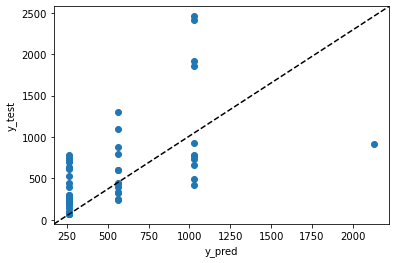

In [22]:
y_pred = regr_tree_hitters.predict(X_test) 
plt.scatter(y_pred,             
            y_test,             
            label = 'Salary') 
plt.plot([0, 1],          
         [0, 1],          
         '--k',          
         transform = plt.gca().transAxes) 
plt.xlabel('y_pred') 
plt.ylabel('y_test') 
mean_squared_error(y_test, y_pred)

#### https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

In [23]:
#score(X, y, sample_weight=None): Returns the coefficient of determination R^2 of the prediction.
#The score is R^2, or (1-u/v). U is the squared sum residual of your prediction, 
#and v is the total square sum(sample sum of square).
print('Training accuracy: ',regr_tree_hitters.score(X_train,y_train))
print('Test Accuracy: ',regr_tree_hitters.score(X_test,y_test))

Training accuracy:  0.6299484220040059
Test Accuracy:  0.302034565609544


In [24]:
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
rmse

453.05127995406707

#### Cost Complexity Prunning
Cost complexity pruning provides an option to control the size of a tree.

Greater values of ccp_alpha increase the number of nodes pruned.

Below shows the effect of ccp_alpha on regularizing the trees and how to choose a ccp_alpha based on validation scores.


Minimal cost complexity pruning recursively finds the node with the “weakest link”. The weakest link is characterized by an effective alpha, where the nodes with the smallest effective alpha are pruned first. To get an idea of what values of ccp_alpha could be appropriate, scikit-learn provides DecisionTreeClassifier.cost_complexity_pruning_path that returns the effective alphas and the corresponding total leaf impurities at each step of the pruning process. As alpha increases, more of the tree is pruned, which increases the total impurity of its leaves.


In [25]:
#from sklearn.tree import DecisionTreeClassifier
path=DecisionTreeRegressor(random_state=1).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

#### https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

In [26]:
# Alternatively
clf = DecisionTreeRegressor(random_state=0)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [27]:
path

{'ccp_alphas': array([0.00000000e+00, 5.95238095e-04, 2.38095238e-03, 5.35714286e-03,
        1.48809524e-02, 1.98412698e-02, 2.41071429e-02, 4.13425929e-02,
        5.95238095e-02, 5.95238095e-02, 5.95238095e-02, 5.95238095e-02,
        5.95238095e-02, 5.95238095e-02, 5.95238095e-02, 5.95238095e-02,
        7.93650794e-02, 7.93650794e-02, 7.93650794e-02, 8.03571429e-02,
        1.21527778e-01, 1.55555556e-01, 1.62259070e-01, 1.78571429e-01,
        2.38095238e-01, 2.38095238e-01, 2.38095238e-01, 2.67857143e-01,
        2.71626984e-01, 3.17460317e-01, 3.17460317e-01, 3.17460317e-01,
        3.34821429e-01, 4.86111111e-01, 4.96031746e-01, 5.35714286e-01,
        5.35714286e-01, 7.20238095e-01, 9.52380952e-01, 9.52380952e-01,
        1.20039683e+00, 1.20714286e+00, 1.28571429e+00, 1.35033951e+00,
        1.48809524e+00, 1.48809524e+00, 1.48809524e+00, 1.48809524e+00,
        1.49349206e+00, 1.53061224e+00, 1.53828656e+00, 1.67658730e+00,
        1.98412698e+00, 2.64544974e+00, 2.84169643

#### In the following plot, the maximum effective alpha value is removed, because it is the trivial tree with only one node.
As alpha increases, more of the tree is pruned, which increases the total impurity of its leaves.

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

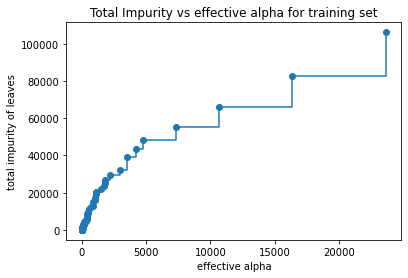

In [28]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
#ax.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

#### Train a decision tree using the effective alphas. The last value in ccp_alphas is the alpha value that prunes the whole tree, leaving the tree, clfs[-1], with one node.

In [29]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeRegressor(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 72761.50444669502


In [30]:
clfs[0].tree_.node_count

365

#### For the remainder of this example, we remove the last element in clfs and ccp_alphas, because it is the trivial tree with only one node. 

Here we show that the number of nodes and tree depth decreases as alpha increases.

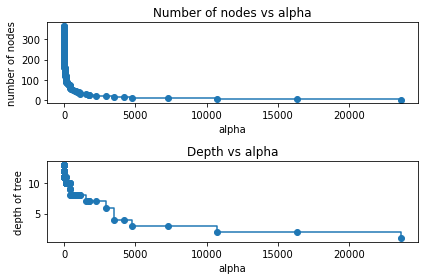

In [31]:
clfs = clfs[:-1] # removing the last element
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

#### Accuracy vs alpha for training and testing sets
When ccp_alpha is set to zero and keeping the other default parameters of DecisionTreeClassifier, the tree overfits, leading to a 100% training accuracy and about 60.79% testing accuracy. As alpha increases, more of the tree is pruned, thus creating a decision tree that generalizes better. In this example, setting ccp_alpha=748.82 maximizes the testing accuracy =0.664038.

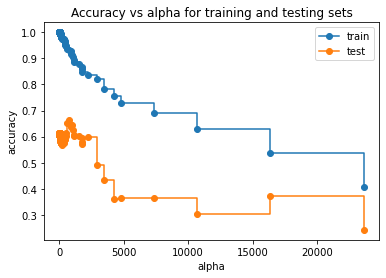

In [32]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [33]:
ccp_alphas

array([0.00000000e+00, 5.95238095e-04, 2.38095238e-03, 5.35714286e-03,
       1.48809524e-02, 1.98412698e-02, 2.41071429e-02, 4.13425929e-02,
       5.95238095e-02, 5.95238095e-02, 5.95238095e-02, 5.95238095e-02,
       5.95238095e-02, 5.95238095e-02, 5.95238095e-02, 5.95238095e-02,
       7.93650794e-02, 7.93650794e-02, 7.93650794e-02, 8.03571429e-02,
       1.21527778e-01, 1.55555556e-01, 1.62259070e-01, 1.78571429e-01,
       2.38095238e-01, 2.38095238e-01, 2.38095238e-01, 2.67857143e-01,
       2.71626984e-01, 3.17460317e-01, 3.17460317e-01, 3.17460317e-01,
       3.34821429e-01, 4.86111111e-01, 4.96031746e-01, 5.35714286e-01,
       5.35714286e-01, 7.20238095e-01, 9.52380952e-01, 9.52380952e-01,
       1.20039683e+00, 1.20714286e+00, 1.28571429e+00, 1.35033951e+00,
       1.48809524e+00, 1.48809524e+00, 1.48809524e+00, 1.48809524e+00,
       1.49349206e+00, 1.53061224e+00, 1.53828656e+00, 1.67658730e+00,
       1.98412698e+00, 2.64544974e+00, 2.84169643e+00, 2.85714286e+00,
      

In [34]:
test_scores

[0.6079297972563134,
 0.6079297290864754,
 0.6079297290864754,
 0.6079297290864754,
 0.6079375485678786,
 0.6079375485678786,
 0.6079348237793589,
 0.6079348237793589,
 0.607948217147506,
 0.607948217147506,
 0.607948217147506,
 0.607948217147506,
 0.607948217147506,
 0.607948217147506,
 0.607948217147506,
 0.607948217147506,
 0.607948217147506,
 0.607951603361675,
 0.6079579480576967,
 0.6079710126066258,
 0.6079710126066258,
 0.6079710126066258,
 0.6079712787072289,
 0.6080049626271198,
 0.6080049626271198,
 0.6080049626271198,
 0.6080049626271198,
 0.6081381945602597,
 0.6081381945602597,
 0.6081381945602597,
 0.6081381945602597,
 0.6080643394470173,
 0.6080643394470173,
 0.6080643394470173,
 0.6080643394470173,
 0.6082832849263082,
 0.6082832849263082,
 0.6081861108274134,
 0.6070622445946587,
 0.6070622445946587,
 0.6070622445946587,
 0.6070622445946587,
 0.6070214389317051,
 0.6070214389317051,
 0.6069793340318415,
 0.6069793340318415,
 0.6069793340318415,
 0.6069793340318415,
 0

In [35]:
type(test_scores)

list

#### Construct the Tree using the best alpha

you can first print the index to see which alpha corresponds to the highest test socore

In [36]:
#operator.itemgetter(n) constructs a callable that assumes an iterable object (e.g. list, tuple, set)
#as input, and fetches the n-th element out of it.

#The enumerate() function assigns an index to each item in an iterable object 
#that can be used to reference the item later.

import operator
index, value = max(enumerate(test_scores), key=operator.itemgetter(1))
print(index)
print(value)
print(len(test_scores))

156
0.6640383763905293
176


In [37]:
ccp_alphas[156]

748.820488800694

In [38]:
test_scores[156]

0.6640383763905293

In [39]:
clfs[156].tree_.node_count

47

In [40]:
clfs[156].tree_.max_depth

8

#### Now create the tree using the depth corresponds to the best alpha

In [41]:
regr_tree_hitters_best_alpha = DecisionTreeRegressor(max_depth=8)
regr_tree_hitters_best_alpha.fit(X, y)

DecisionTreeRegressor(max_depth=8)

#### Alternatively to view the tree: The tree is exported in carseat_tree_ba.dot file, visualize using http://www.webgraphviz.com/ by copying the data from the ‘tree.dot’ file.